Error Map

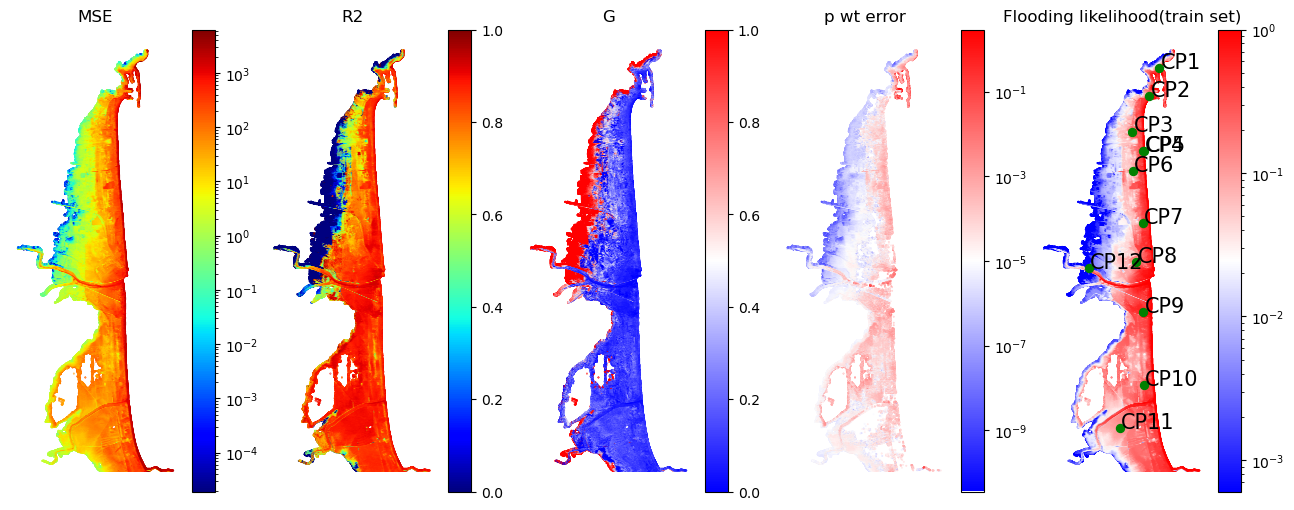

In [6]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.colors as mplcolors
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import r2_score
import xarray as xr

#select particular representative gauge
reg = 'CT'
list_size = ['892','1658','3454','7071']   
columnname = str(38)
mask_size = '892'
train_size = list_size[1]
test_size = 3
idx= np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/lat_lon_idx_{reg}_{mask_size}.npy')
idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/PTHA/Grid_scores_{train_size}.txt', sep=",")

#add columns to to the idx array
nflood_grids = len(idx)


idx = np.c_[idx,idx_val['mse'],idx_val['r2'],idx_val['Gfit'],idx_val['ptha_err'],idx_val['count_train']]

# Using enumerate to add index to the list of coordinates
control_points =  [[37.5022,15.0960],
            [37.48876,15.08936],
            [37.47193,15.07816],
            [37.46273,15.08527],
            [37.46252,15.08587],
            [37.45312,15.07874],
            [37.42821,15.08506],
            [37.40958,15.08075],
            [37.38595,15.08539],
            [37.35084,15.08575],
            [37.33049,15.07029],
            [37.40675,15.05037]]
#keep every second element from the list
# control_points = control_points[::2]
coordinates_list = pd.DataFrame(control_points,columns=['lat','lon'])
coordinates_list['id'] = coordinates_list.index+1
CP_list = [573785, 561728, 530792, 507751, 507274, 481772, 400027, 318807, 229769, 155881, 82539, 303797]
coordinates_list['idx'] = CP_list
coordinates_list['m'] = idx[CP_list, 1]
coordinates_list['n'] = idx[CP_list, 0]


fig, axs = plt.subplots(1, 5, figsize=(16, 6))

# Plot mse
mse = axs[0].scatter(idx[:, 1], idx[:, 0], c=idx[:, 4], s=0.1, cmap='jet',norm=mplcolors.LogNorm())
fig.colorbar(mse, ax=axs[0])
axs[0].set_title('MSE')
axs[0].set_axis_off()

# Plot r2
r2 = axs[1].scatter(idx[:, 1], idx[:, 0], c=idx[:, 5], s=0.1, cmap='jet', vmin=0, vmax=1)
fig.colorbar(r2, ax=axs[1])
axs[1].set_title('R2')
axs[1].set_axis_off()

# Plot g
g = axs[2].scatter(idx[:, 1], idx[:, 0], c=idx[:, 6], s=0.1, cmap='bwr', vmin=0, vmax=1)
fig.colorbar(g, ax=axs[2])
axs[2].set_title('G')
axs[2].set_axis_off()

# Plot ptha error
ptha = axs[3].scatter(idx[:, 1], idx[:, 0], c=idx[:, 7], s=0.1, cmap='bwr',norm=mplcolors.LogNorm())
fig.colorbar(ptha, ax=axs[3])
axs[3].set_title('p wt error')
axs[3].set_axis_off()

# Plot control points/count
flood = axs[4].scatter(idx[:, 1], idx[:, 0], c=idx[:, 8], s=0.1, cmap='bwr',norm=mplcolors.LogNorm())
fig.colorbar(flood, ax=axs[4])
axs[4].scatter(coordinates_list['m'], coordinates_list['n'], marker='o', s=33, c='green')
for i, txt in enumerate(coordinates_list['id']):
    axs[4].annotate('CP' + str(txt), (coordinates_list['m'][i] + 10, coordinates_list['n'][i]), fontsize=15)
axs[4].set_title('Flooding likelihood(train set)')
axs[4].set_axis_off()

plt.savefig(f'plots/Grid_scores_{train_size}_{reg}.png', dpi=300)

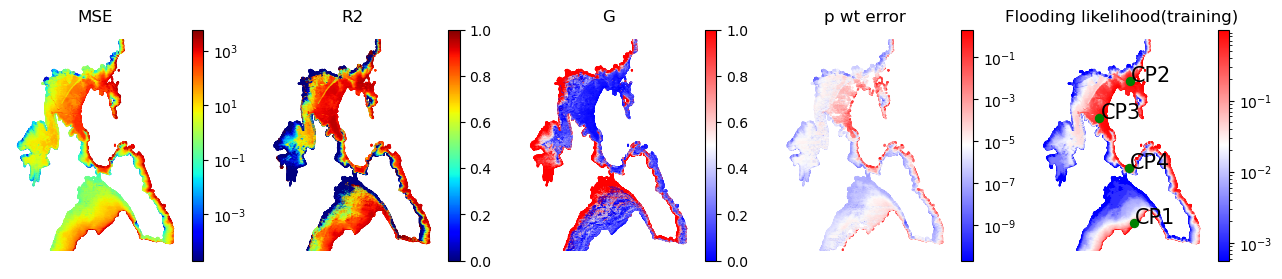

In [5]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.colors as mplcolors
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import r2_score
import xarray as xr

#select particular representative gauge
reg = 'SR'
list_size = ['961','1773','3669','6941']
mask_size = '961'
train_size = list_size[1]
idx= np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/lat_lon_idx_{reg}_{mask_size}.npy')
idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/PTHA/Grid_scores_{train_size}.txt', sep=",")

#add columns to to the idx array
nflood_grids = len(idx)

idx = np.c_[idx,idx_val['mse'],idx_val['r2'],idx_val['Gfit'],idx_val['ptha_err'],idx_val['count_train']]

# Using enumerate to add index to the list of coordinates
control_points = [[37.01,15.29],
            [37.06757,15.28709],
            [37.05266,15.26536],
            [37.03211,15.28632]]
#keep every second element from the list
# control_points = control_points[::2]
coordinates_list = pd.DataFrame(control_points,columns=['lat','lon'])
coordinates_list['id'] = coordinates_list.index+1
CP_list = [29720, 202349, 153030, 94497]
coordinates_list['idx'] = CP_list
coordinates_list['m'] = idx[CP_list, 1]
coordinates_list['n'] = idx[CP_list, 0]

fig, axs = plt.subplots(1, 5, figsize=(16, 3))

# Plot mse
mse = axs[0].scatter(idx[:, 1], idx[:, 0], c=idx[:, 4], s=0.1, cmap='jet',norm=mplcolors.LogNorm())
fig.colorbar(mse, ax=axs[0])
axs[0].set_title('MSE')
axs[0].set_axis_off()

# Plot r2
r2 = axs[1].scatter(idx[:, 1], idx[:, 0], c=idx[:, 5], s=0.1, cmap='jet', vmin=0, vmax=1)
fig.colorbar(r2, ax=axs[1])
axs[1].set_title('R2')
axs[1].set_axis_off()

# Plot g
g = axs[2].scatter(idx[:, 1], idx[:, 0], c=idx[:, 6], s=0.1, cmap='bwr', vmin=0, vmax=1)
fig.colorbar(g, ax=axs[2])
axs[2].set_title('G')
axs[2].set_axis_off()

# Plot ptha error
ptha = axs[3].scatter(idx[:, 1], idx[:, 0], c=idx[:, 7], s=0.1, cmap='bwr',norm=mplcolors.LogNorm())
fig.colorbar(ptha, ax=axs[3])
axs[3].set_title('p wt error')
axs[3].set_axis_off()

# Plot control points/count
flood = axs[4].scatter(idx[:, 1], idx[:, 0], c=idx[:, 8], s=0.1, cmap='bwr',norm=mplcolors.LogNorm())
fig.colorbar(flood, ax=axs[4])
axs[4].scatter(coordinates_list['m'], coordinates_list['n'], marker='o', s=33, c='green')
for i, txt in enumerate(coordinates_list['id']):
    axs[4].annotate('CP' + str(txt), (coordinates_list['m'][i] + 10, coordinates_list['n'][i]), fontsize=15)
axs[4].set_title('Flooding likelihood(training)')
axs[4].set_axis_off()

plt.savefig(f'plots/Grid_scores_{train_size}_{reg}.png', dpi=300)

Maps - Event Locations

/tmp/ipykernel_2972715/1414379333.py:14: DtypeWarning: Columns (6,7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  data_events = pd.read_csv('../../resources/processed/allinfo_eventsBS_PS53550.txt',sep=',')


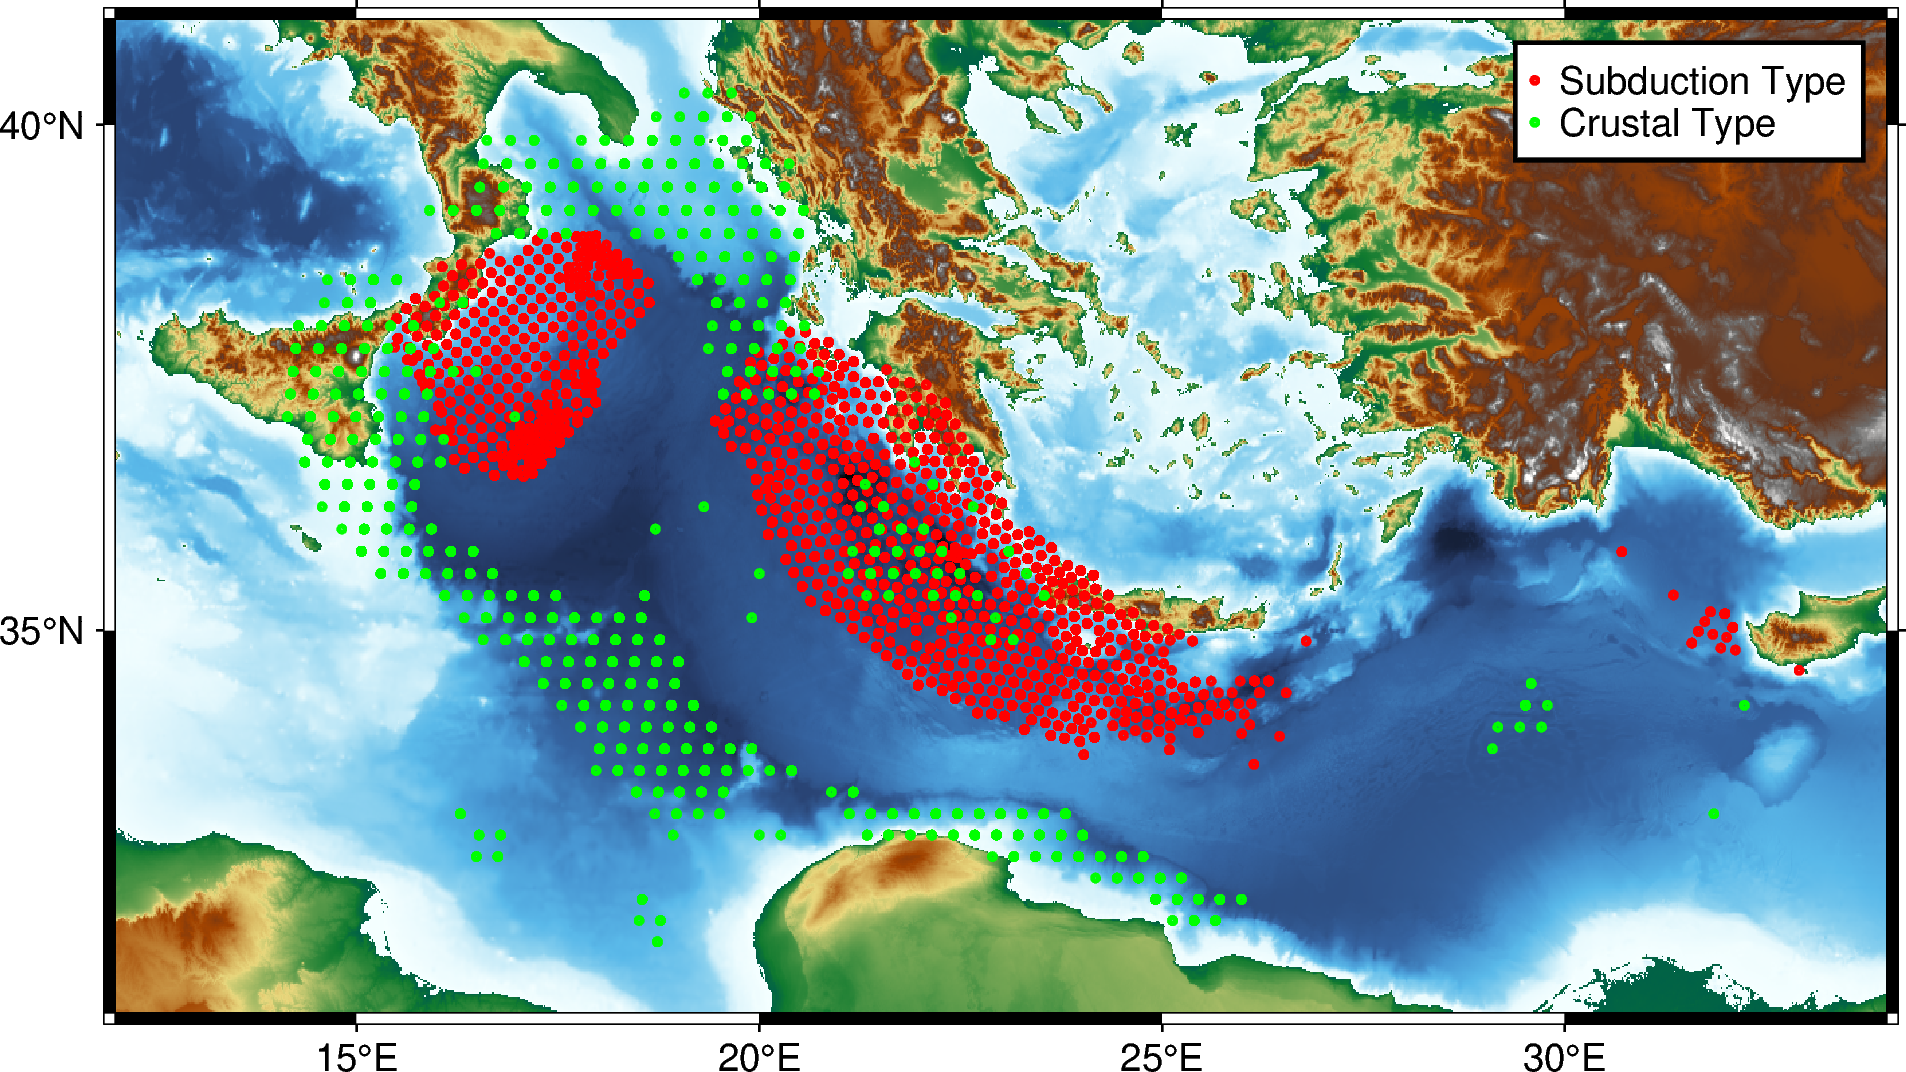

In [1]:
import os
import numpy as np
import pygmt
import pandas as pd

fig = pygmt.Figure()

# Load the grid
grid = pygmt.datasets.load_earth_relief(resolution="01m",region=[12, 34, 31, 41])
fig = pygmt.Figure()
fig.grdimage(grid=grid, projection="M15c", frame="a", cmap="geo")

# Load the earthquake events data
data_events = pd.read_csv('../../resources/processed/allinfo_eventsBS_PS53550.txt',sep=',')


# Filter data by event type
ps_data = data_events[data_events['Type'] == 'PS']
bs_data = data_events[data_events['Type'] == 'BS']

# Create scatter plots for PS and BS data
fig.plot(
    x=ps_data['lon'],
    y=ps_data['lat'],
    style="c0.05",
    pen="1p,red",
    label="Subduction Type",
)
fig.plot(
    x=bs_data['lon'],
    y=bs_data['lat'],
    style="c0.05",
    pen="1p,green",
    label="Crustal Type",
)

# Add a legend	
fig.legend()

# Save or display the map
fig.savefig("/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/CT/results/poster_map_eq.png")
fig.show()


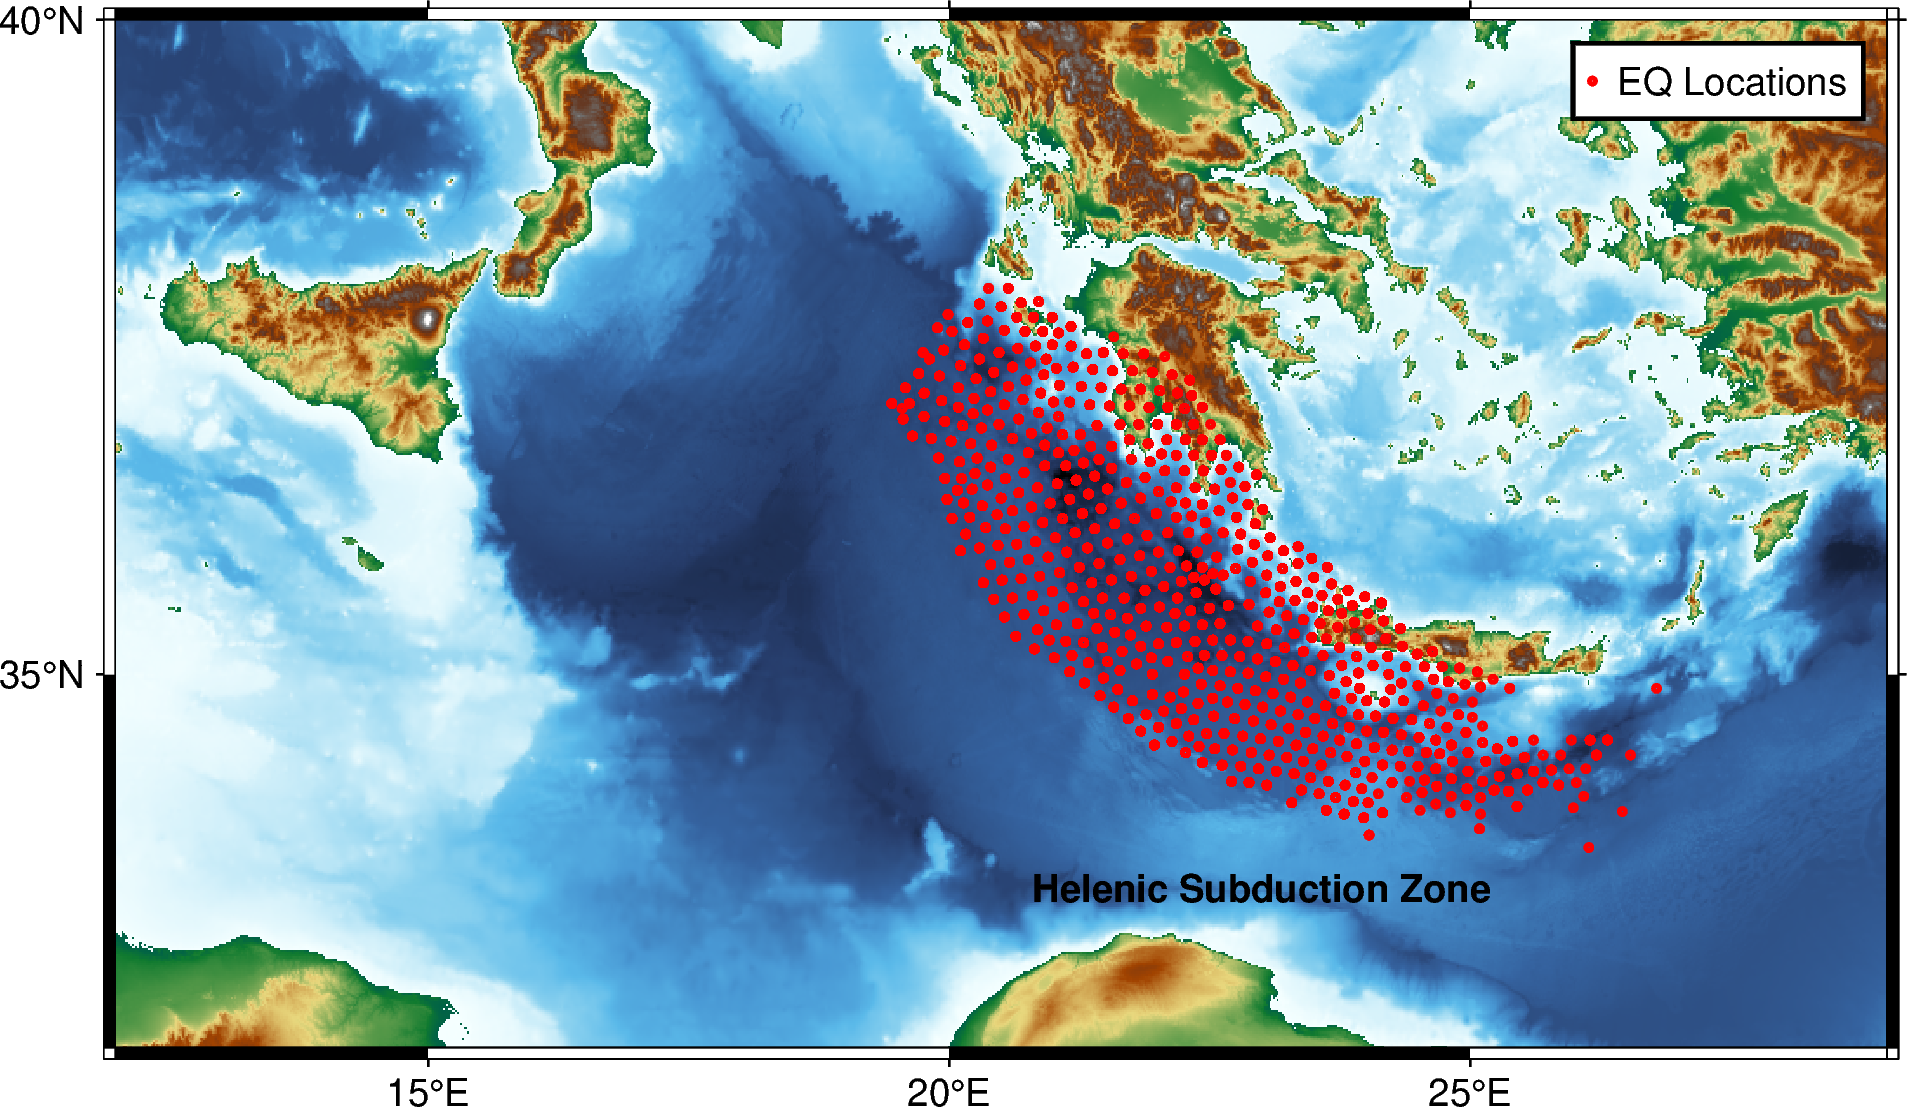

In [1]:
import os
import numpy as np
import pygmt
import pandas as pd

fig = pygmt.Figure()

# Load the grid
grid = pygmt.datasets.load_earth_relief(resolution="01m",region=[12, 29, 32, 40])
fig = pygmt.Figure()
fig.grdimage(grid=grid, projection="M15c", frame="a", cmap="geo")

# Load the earthquake events data
data_events = pd.read_csv('../../data/info/PS_Helenic_sampling_input_CT_41.csv',sep=',')

# Create scatter plots for PS and BS data
fig.plot(
    x=data_events['lon'],
    y=data_events['lat'],
    style="c0.05",
    pen="1p,red",
    label="EQ Locations",
)

#annotate subduction zone with text wrapped at 40 characters

fig.text(
    x=23,
    y=33.3,
    text="Helenic Subduction Zone",
    font="Helvetica-Bold",

)

# Add a legend	
fig.legend()

# Save or display the map
fig.savefig("plots/poster_map_eq.png")
fig.show()


Study Site

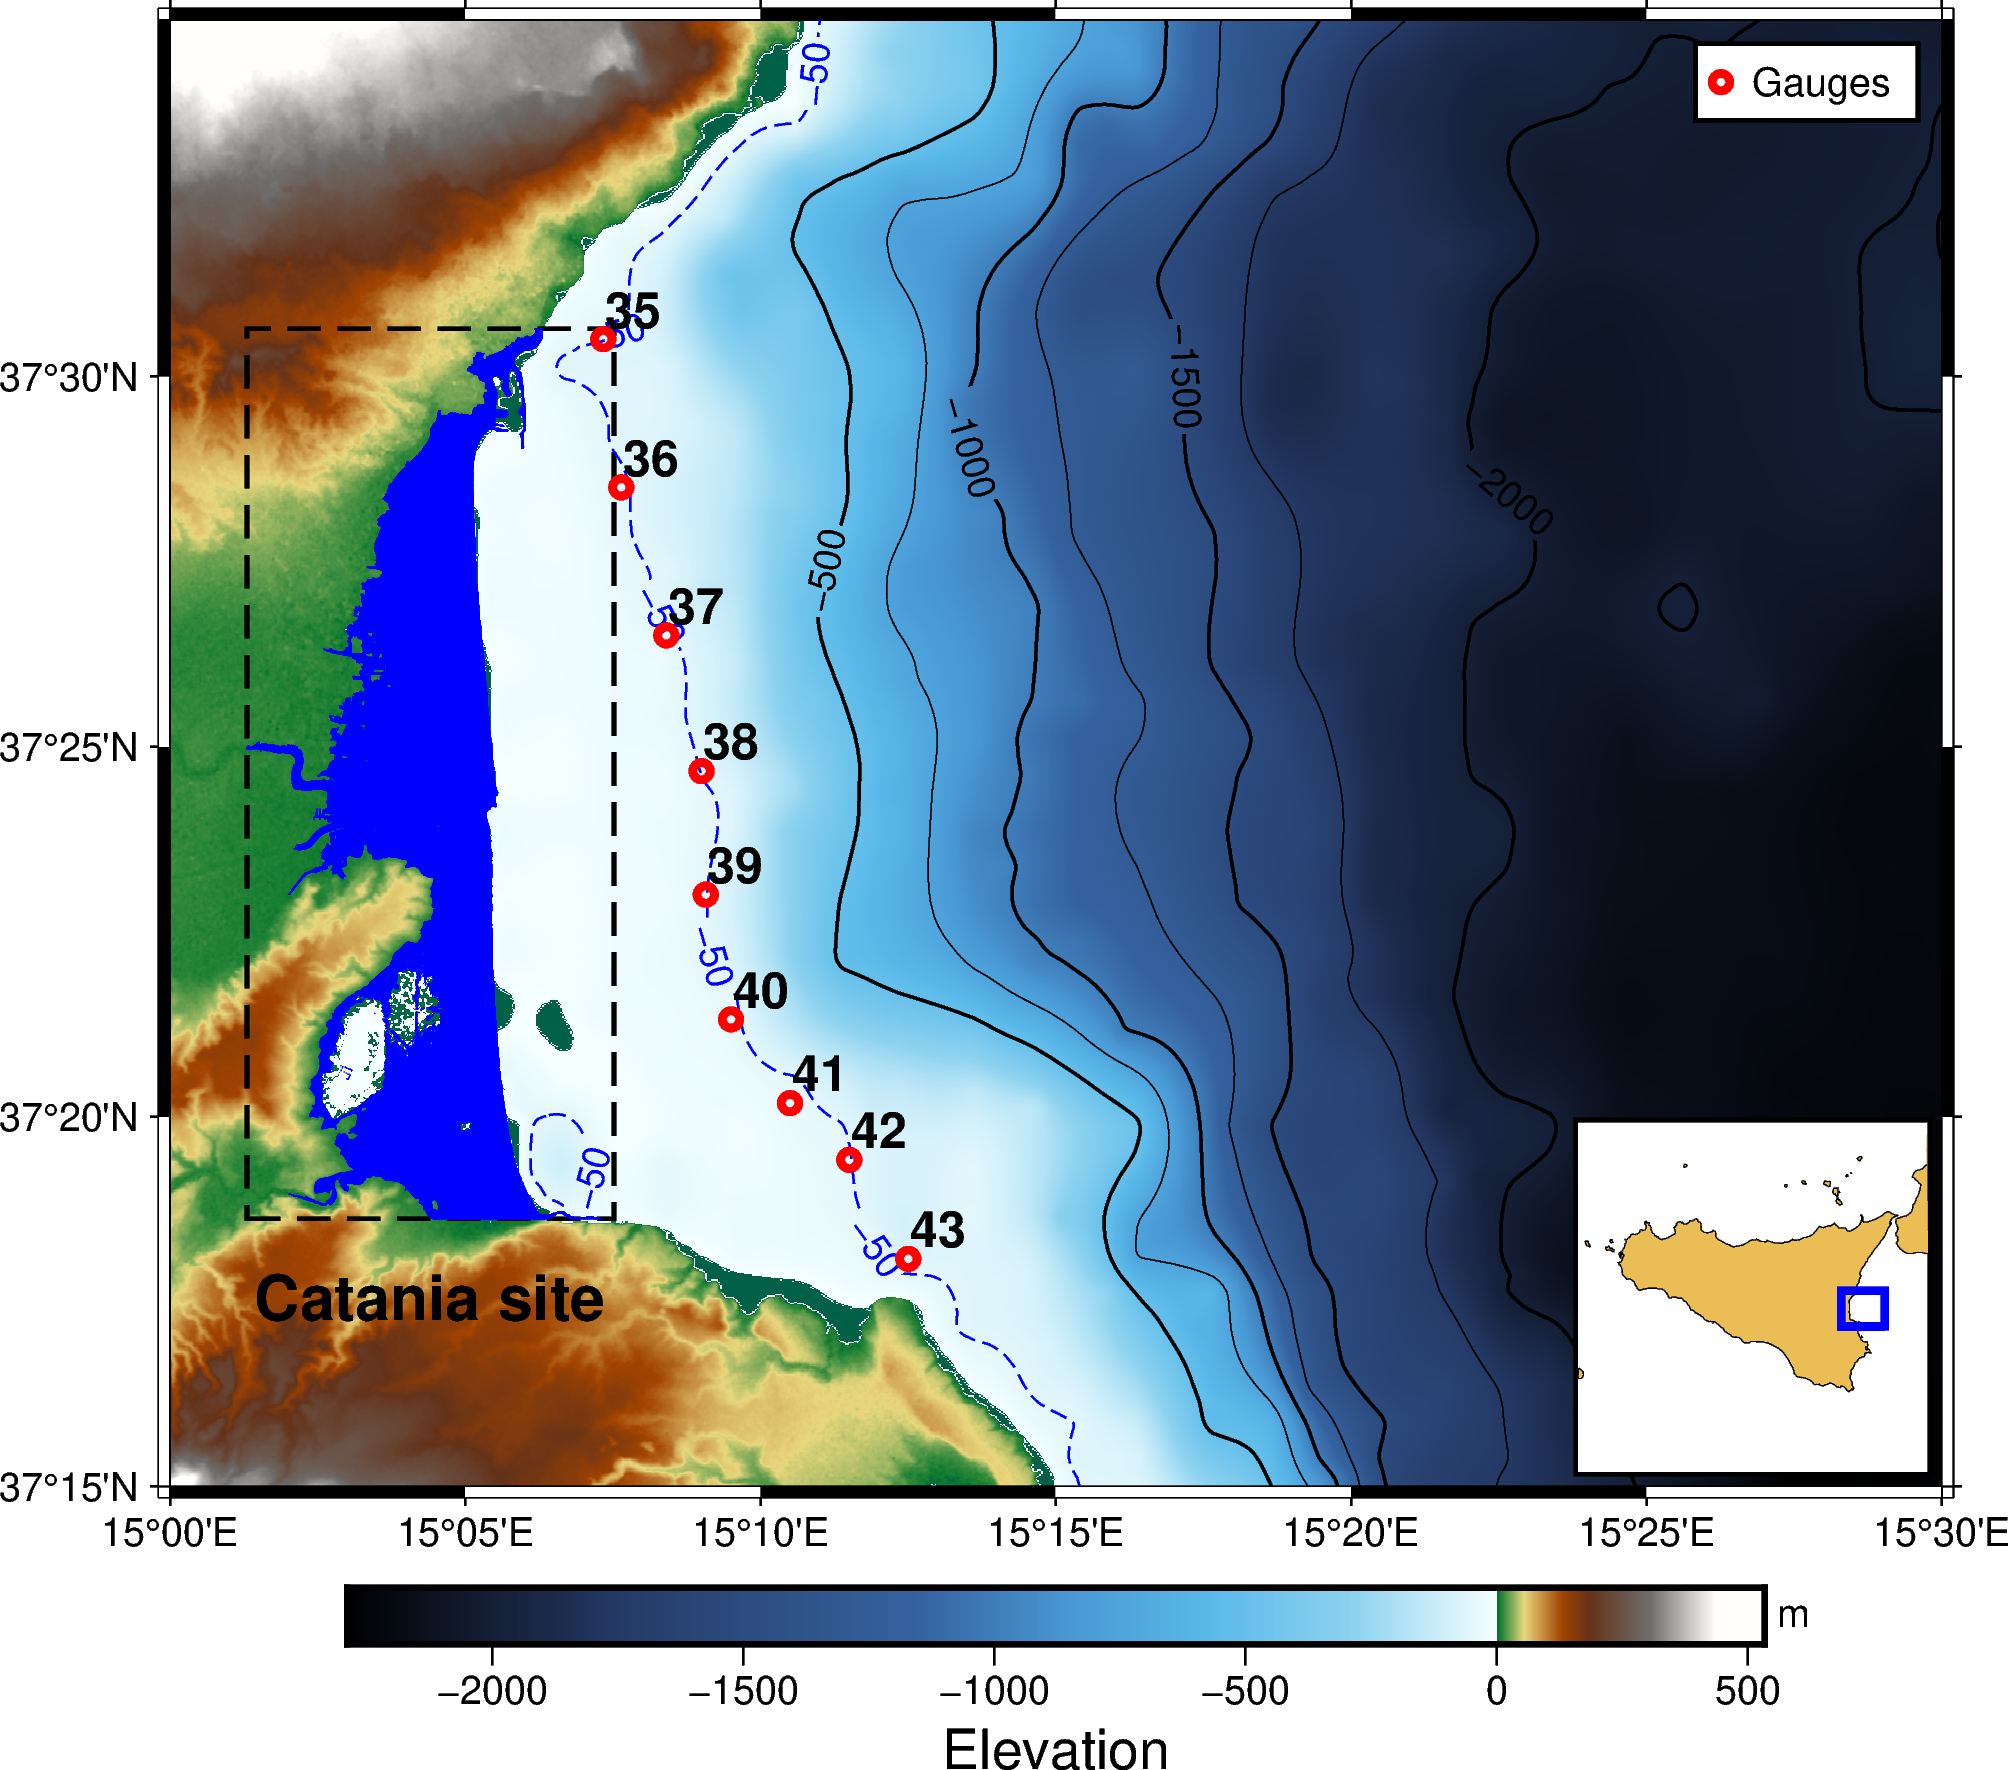

In [1]:
import pygmt
import xarray as xr
import pandas as pd
import numpy as np

#main plot region
region=[15, 15.5,37.25, 37.58]

#read grid lat lon info from text file
grid_info = pd.read_csv('../../data/processed/lat_lon_idx_CT_1650.txt',sep=',')
#add columns name
grid_info.columns = ['m','n','lat','lon']

# Load the grid
grid_CT = xr.open_dataset('../../data/processed/CT_defbathy.nc',engine='netcdf4')

grid = pygmt.datasets.load_earth_relief(
    resolution="01s", region=region, registration="gridline"
)

#read offshore points from 
gauges = pd.read_csv('../../resources/raw/pois_depth.csv',sep=',')

CT_gauges = list(range(35,44))

#combine both
selected_gauges =  gauges.iloc[CT_gauges]

fig = pygmt.Figure()

fig.grdimage(grid=grid, frame="a", projection="M15c", cmap="geo",transparency=50)

#plot CT and SR grids area as rectangles
fig.plot(
    data = np.array([[float(grid_CT['x'].min().values),
                    float(grid_CT['y'].min().values),
                    float(grid_CT['x'].max()),
                    float(grid_CT['y'].max())]]),
    style='r+s',
    pen= "1p,black,-",)

#plot grids from text file
fig.plot(
        x = grid_info['lon'],
        y = grid_info['lat'],
        transparency=90,
        style="s0.0022c",
        pen="0.005p,blue",
)

# fig.coast(shorelines="2p,gray",region=[14.9, 15.5,37.25, 37.5888],frame="a", projection="M15c",)
fig.grdcontour(grid=grid, interval=250, annotation=500,limit=[-2000, -500])
fig.grdcontour(grid=grid, interval=50, annotation=50,limit=[-56, -49], pen="0.5p,blue,--",label_placement="d3c")

fig.plot(
    x=selected_gauges['lon'],
    y=selected_gauges['lat'],
    style="c0.15",
    pen="2p,red",
    label="Gauges ",
)

#add annotations for gauges
for i in range(len(selected_gauges)):
    fig.text(
        x=selected_gauges['lon'].iloc[i],
        y=selected_gauges['lat'].iloc[i],
        text=selected_gauges['id'].iloc[i],
        font="12p,Helvetica-Bold,black",
        justify="CM",
        offset="0.25c",
    )


fig.text(
    x=15.07,    
    y=37.29,
    text="Catania site",
    font="15p,Helvetica-Bold,black",
    justify="CM",
    offset="0.1c",
)


with fig.inset(position="jBR+w3c/3c+o0.1c", box="+gwhite+p1p"):
    # Plot the Sicily main land in the inset using coast. "U54S/M?" means UTM
    # projection with map width automatically determined from the inset width.
    # Highlight the Japan area in "lightbrown"
    # and draw its outline with a pen of "0.2p".
    fig.coast(
        region=[12, 16, 36, 39],
        projection="U33S/?",
        dcw="IT+glightbrown+p0.2p",
        area_thresh=10000,
    )
    # Plot a rectangle ("r") in the inset map to show the area of the main figure.
    # "+s" means that the first two columns are the longitude and latitude of
    # the bottom left corner of the rectangle, and the last two columns the
    # longitude and latitude of the uppper right corner.
    rectangle = [[region[0], region[2], region[1], region[3]]]
    fig.plot(data=rectangle, style="r+s", pen="2p,blue")

fig.colorbar(frame=["a500", "x+lElevation", "y+lm"])
fig.legend()
fig.savefig('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/CT/results/poster_regions.png')
fig.show()


plot [WARNING]: Length <unit> r not supported - revert to default unit [cm]
plot [WARNING]: 0.15+ not a valid number and may not be decoded properly.


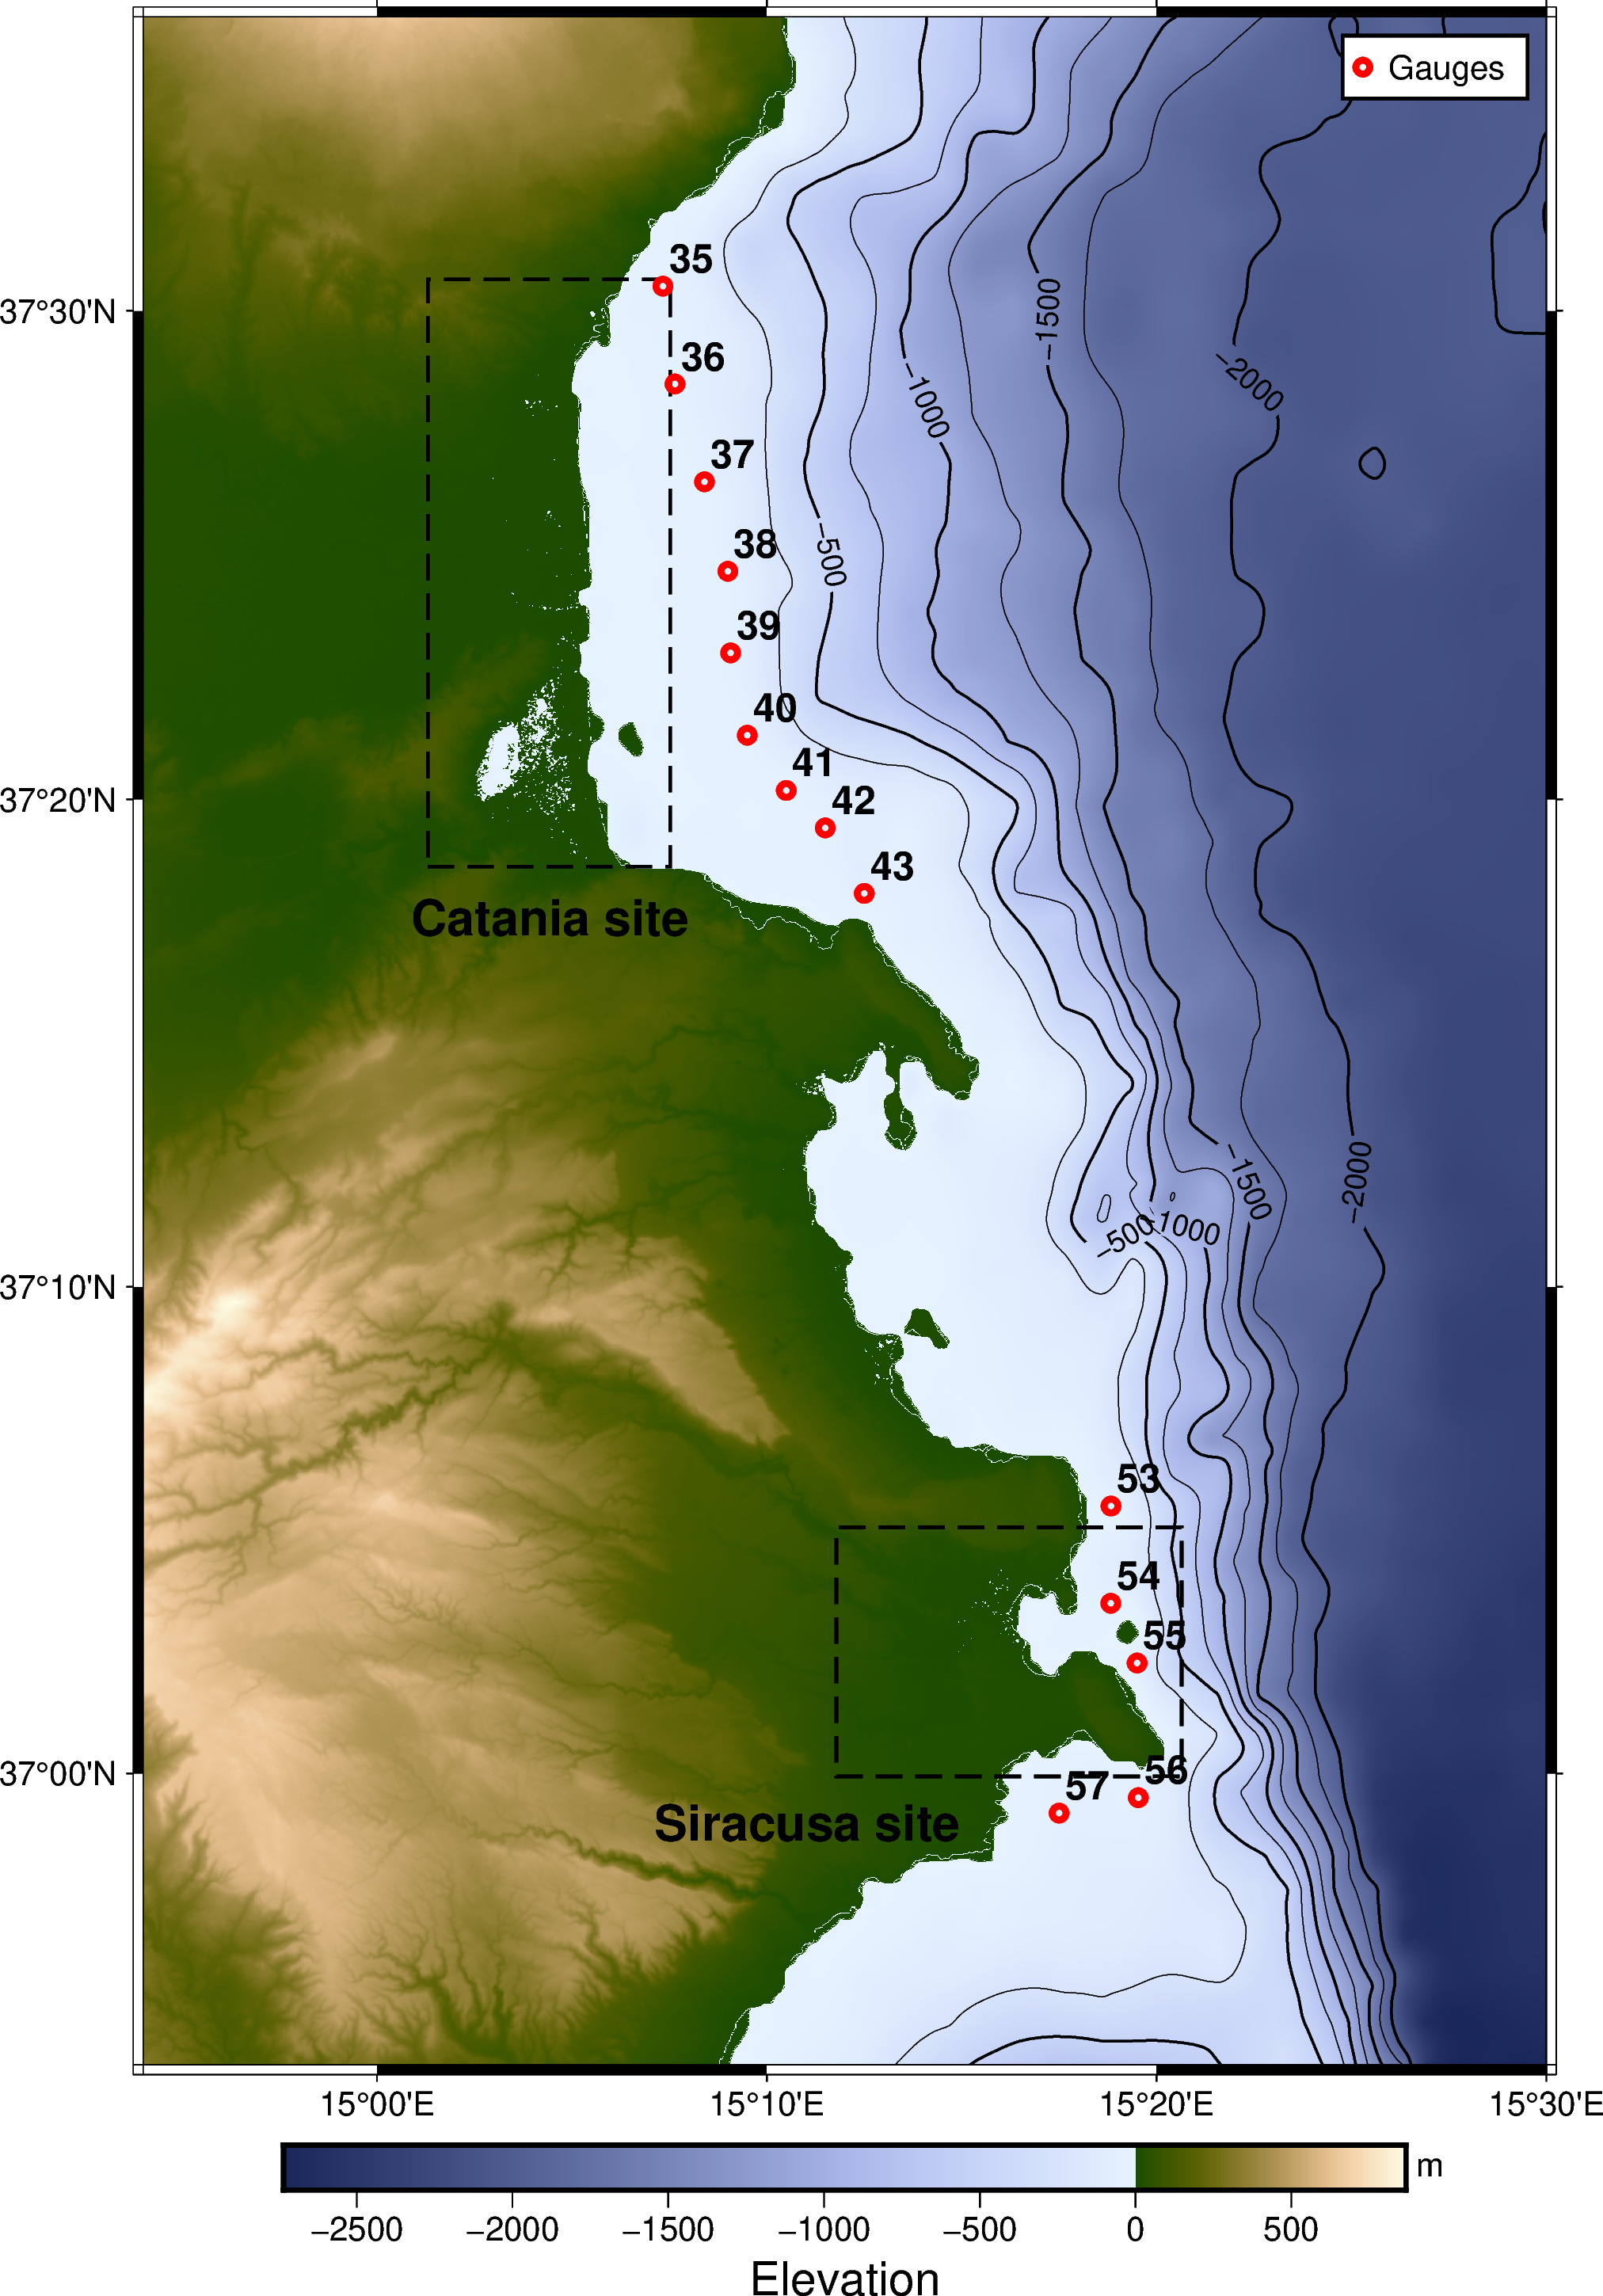

In [1]:
import pygmt
import xarray as xr
import pandas as pd
import numpy as np


# Load the grid
grid_CT = xr.open_dataset('../../data/processed/CT_defbathy.nc',engine='netcdf4')
grid_SR = xr.open_dataset('../../data/processed/SR_defbathy.nc',engine='netcdf4')

grid = pygmt.datasets.load_earth_relief(
    resolution="01s", region=[14.9, 15.5,36.9, 37.6], registration="gridline"
)

#read offshore points from 
gauges = pd.read_csv('../../resources/raw/pois_depth.csv',sep=',')

CT_gauges = list(range(35,44))
SR_gagues = list(range(53,58))

#combine both
selected_gauges =  gauges.iloc[CT_gauges + SR_gagues]

fig = pygmt.Figure()
fig.grdimage(grid=grid, frame="a", projection="M15c", cmap="oleron")
fig.grdcontour(grid=grid, interval=250, annotation=500,limit=[-2000, -10])
# fig.coast(shorelines="2p,gray")

#plot CT and SR grids area as rectangles
fig.plot(
    data = np.array([[float(grid_CT['x'].min().values),
                    float(grid_CT['y'].min().values),
                    float(grid_CT['x'].max()),
                    float(grid_CT['y'].max())]]),
    style='r+s',
    pen= "1p,black,-",)

fig.plot(
    data = np.array([[float(grid_SR['x'].min().values),
                    float(grid_SR['y'].min().values),
                    float(grid_SR['x'].max()),
                    float(grid_SR['y'].max())]]),
    style='r+s',
    pen= "1p,black,-",)

fig.plot(
    x=selected_gauges['lon'],
    y=selected_gauges['lat'],
    style="c0.15+r",
    pen="2p,red",
    label="Gauges ",
)

#add annotations for gauges
for i in range(len(selected_gauges)):
    fig.text(
        x=selected_gauges['lon'].iloc[i],
        y=selected_gauges['lat'].iloc[i],
        text=selected_gauges['id'].iloc[i],
        font="12p,Helvetica-Bold,black",
        justify="CM",
        offset="0.3c",
    )


fig.text(
    x=15.07,    
    y=37.29,
    text="Catania site",
    font="15p,Helvetica-Bold,black",
    justify="CM",
    offset="0.1c",
)

fig.text(
    x=15.18,    
    y=36.98,
    text="Siracusa site",
    font="15p,Helvetica-Bold,black",
    justify="CM",
    offset="0.1c",
)

fig.colorbar(frame=["a500", "x+lElevation", "y+lm"])
fig.legend()
fig.savefig('./plots/pygmt_regions.png')
fig.show()
